### Libraries

In [37]:
import re
import os
import numpy as np
from astropy.io import ascii
from astropy.io import fits
from astropy.table import Table
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
from matplotlib.ticker import AutoMinorLocator
from astropy.constants import L_sun
from matplotlib import gridspec
import astropy.units as u
from math import pi
import gc
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from astropy.table import Column
from scipy.stats import bootstrap

from __future__ import annotations
import os
import json
from astropy.cosmology import FlatwCDM
'''
import pymultinest
import corner
from getdist import plots, MCSamples
import scipy.optimize as op
from scipy import stats
from scipy.stats import norm
from astropy.time import Time
import matplotlib.dates as mdates

from venn import venn
import requests

'''
!pip install venn

from venn import venn
import requests

In [38]:
def HyperLeda(filename):
    """
    Lee una tabla tipo NED/HyperLEDA ignorando comentarios y headers,
    devolviendo todas las columnas en un DataFrame de pandas.
    """

    # Leer el archivo ignorando líneas de comentario
    df = pd.read_csv(
        filename,
        comment="#",
        sep=",",
        engine="python"
    )

    # Limpiar nombres de columnas
    df.columns = [c.strip() for c in df.columns]

    #Convertir todo lo que se pueda a numérico
    #for col in df.columns:
        #df[col] = pd.to_numeric(df[col], errors="ignore")

    return df

def SIMBAD(filename):
    """
    Lee una tabla tipo NED/HyperLEDA ignorando comentarios y headers,
    devolviendo todas las columnas en un DataFrame de pandas.
    """

    # Leer el archivo ignorando líneas de comentario
    df = pd.read_csv(
        filename,
        comment="#",
        sep="|",
        engine="python"
    )

    # Limpiar nombres de columnas
    df.columns = [c.strip() for c in df.columns]

    #Convertir todo lo que se pueda a numérico
    #for col in df.columns:
        #df[col] = pd.to_numeric(df[col], errors="ignore")

    return df

def NED(filename):
    """
    Lee una tabla tipo NED/HyperLEDA ignorando comentarios y headers,
    devolviendo todas las columnas en un DataFrame de pandas.
    """

    # Leer el archivo ignorando líneas de comentario
    df = pd.read_csv(
        filename,
        comment="#",
        sep=",",
        engine="python"
    )

    # Limpiar nombres de columnas
    df.columns = [c.strip() for c in df.columns]

    #Convertir todo lo que se pueda a numérico
    #for col in df.columns:
        #df[col] = pd.to_numeric(df[col], errors="ignore")

    return df

def Prev_Fer(filename):
    """
    Lee una tabla tipo NED/HyperLEDA ignorando comentarios y headers,
    devolviendo todas las columnas en un DataFrame de pandas.
    """

    # Leer el archivo ignorando líneas de comentario
    df = pd.read_csv(
        filename,
        comment="#",
        sep=",",
        engine="python"
    )

    # Limpiar nombres de columnas
    df.columns = [c.strip() for c in df.columns]

    #Convertir todo lo que se pueda a numérico
    #for col in df.columns:
        #df[col] = pd.to_numeric(df[col], errors="ignore")

    return df

In [39]:
df_dist = NED("/home/hollman/HIIGalaxies/Modulus/ref_NED/19.NGC2500.csv")

df_dist['Method'] = df_dist['Method'].str.strip()
df_dist['Reference'] = df_dist['Reference'].str.strip()
df_dist = df_dist[df_dist['Reference'].str[0:4].astype(int) >= 2000]


PLRC = np.unique(df_dist[(df_dist['Method']=='Cepheids')    &   (df_dist['err(m-M)'].notnull())]['Reference'])
TRGB = np.unique(df_dist[(df_dist['Method']=='TRGB')    &   (df_dist['err(m-M)'].notnull())]['Reference'])
RRLy = np.unique(df_dist[(df_dist['Method']=='RR Lyrae')    &   (df_dist['err(m-M)'].notnull())]['Reference'])

print(len(PLRC), len(TRGB), len(RRLy))

df_dist

0 1 0


,No.,(m-M),err(m-M),Distance,Method,Reference,Notes,SN Name,Redshift,H0,LMCModulus
0,1,30.18,0.46,10.9,TRGB,2018ApJS..235...23S,NaN,NaN,NaN,NaN,NaN


In [40]:
home = '/home/hollman/HIIGalaxies/Modulus/ref_NED'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

for b in list_files:
    df_dist = NED(f"/home/hollman/HIIGalaxies/Modulus/ref_NED/{b}")
    df_dist['Method'] = df_dist['Method'].str.strip()
    df_dist['Reference'] = df_dist['Reference'].str.strip()
    df_dist = df_dist[df_dist['Reference'].str[0:4].astype(int) >= 2000]


    PLRC = np.unique(df_dist[(df_dist['Method']=='Cepheids')    ]['Reference']) #&   (df_dist['err(m-M)'].notnull())
    TRGB = np.unique(df_dist[(df_dist['Method']=='TRGB')    ]['Reference']) # &   (df_dist['err(m-M)'].notnull())
    RRLy = np.unique(df_dist[(df_dist['Method']=='RR Lyrae')    ]['Reference']) #&   (df_dist['err(m-M)'].notnull())

    print(len(PLRC),"	", len(TRGB),"	", len(RRLy))
    #print(b,"     ",len(PLRC),"	", len(TRGB),"	", len(RRLy),"\n")
    #b,"     ", ,"\n"


64 	 8 	 40
1 	 9 	 1
0 	 4 	 0
16 	 17 	 6
12 	 8 	 0
14 	 7 	 0
3 	 3 	 0
10 	 0 	 0
1 	 7 	 0
4 	 5 	 0
8 	 0 	 0
11 	 0 	 0
9 	 0 	 0
0 	 8 	 0
0 	 3 	 0
25 	 6 	 0
1 	 4 	 0
14 	 9 	 3
0 	 0 	 0
0 	 1 	 0
0 	 0 	 0
11 	 4 	 0
8 	 1 	 0
12 	 4 	 0
10 	 0 	 0
16 	 0 	 0
10 	 0 	 0
20 	 0 	 0
9 	 0 	 0
1 	 4 	 0
0 	 2 	 0
0 	 8 	 0
3 	 2 	 0


In [43]:
df_dist = HyperLeda(f"/home/hollman/HIIGalaxies/Modulus/ref_HyperLeda/0.LMC.csv")
df_dist = df_dist[df_dist['bibcode'].str[0:4].astype(int) >= 2000]
df_dist['$link[method_method]'] = df_dist['$link[method_method]'].str.strip()
df_dist['bibcode'] = df_dist['bibcode'].str.strip()

PLRC = np.unique(df_dist[df_dist['$link[method_method]']=='Cepheids']['bibcode'])
TRGB = np.unique(df_dist[df_dist['$link[method_method]']=='TRGB']['bibcode'])
RRLy = np.unique(df_dist[df_dist['$link[method_method]']=='RRLyrae']['bibcode'])

#print(b,"     ",len(PLRC),"	", len(TRGB),"	", len(RRLy),"\n")

df_dist

,$objname,$j2000,modulus,e_modulus,flimit,fquality,distance,e_distance,flimit.1,fquality.1,modc,$link[method_method],$link[iref_iref],$link[bibref_bibcode],$link[calib_calib_bibcode],pgc,dataset,bibcode,calib_bibcode,calibsys
1,ESO056-115,J052334.6-694522,18.5070,0.003000,NaN,NaN,0.050281,0.000070,NaN,NaN,18.507000,Cepheids,52042,Musella+2016,Cepheids:Fiorentino+2007,17223,52042,2016MNRAS.457.3084M,2007A&A...476..863F,NaN
2,ESO056-115,J052334.6-694522,18.5500,0.060000,NaN,NaN,0.051286,0.001437,NaN,NaN,18.534862,Cepheids,51879,Fouque+2003,Cepheids:Fouque+2003,17223,51879,2003LNP...635...21F,2003LNP...635...21F,NaN
4,ESO056-115,J052334.6-694522,18.3700,0.000000,NaN,NaN,0.047206,0.000000,NaN,NaN,18.398429,Cepheids,51470,Paturel+2002,Cepheids:Lanoix+1999,17223,51470,2002A&A...389...19P,1999MNRAS.308..969L,NaN
5,ESO056-115,J052334.6-694522,18.3400,0.060000,NaN,NaN,0.046559,0.001304,NaN,NaN,18.340000,Cepheids,51540,An+2007,,17223,51540,2007ApJ...671.1640A,NaN,An+2007
6,ESO056-115,J052334.6-694522,18.4000,0.050000,NaN,NaN,0.047863,0.001115,NaN,NaN,18.400000,Cepheids,51538,Benedict+2007,,17223,51538,2007AJ....133.1810B,NaN,Benedict+2007
8,ESO056-115,J052334.6-694522,18.3900,0.050000,NaN,NaN,0.047643,0.001110,NaN,NaN,18.389999,Cepheids,51539,van Leeuwen+2007,,17223,51539,2007MNRAS.379..723V,NaN,vanLeuwen+2007
9,ESO056-115,J052334.6-694522,18.4500,0.050000,NaN,NaN,0.048978,0.001141,NaN,NaN,18.450001,Cepheids,51539,van Leeuwen+2007,,17223,51539,2007MNRAS.379..723V,NaN,vanLeuwen+2007
10,ESO056-115,J052334.6-694522,18.4700,0.030000,NaN,NaN,0.049431,0.000688,NaN,NaN,18.469999,Cepheids,51539,van Leeuwen+2007,,17223,51539,2007MNRAS.379..723V,NaN,vanLeuwen+2007
11,ESO056-115,J052334.6-694522,18.5200,0.030000,NaN,NaN,0.050582,0.000704,NaN,NaN,18.520000,Cepheids,51539,van Leeuwen+2007,,17223,51539,2007MNRAS.379..723V,NaN,vanLeuwen+2007
12,ESO056-115,J052334.6-694522,18.4100,0.160000,NaN,NaN,0.048084,0.003677,NaN,NaN,18.410000,Cepheids,51542,Macri+2006,,17223,51542,2006ApJ...652.1133M,NaN,NaN


In [44]:
home = '/home/hollman/HIIGalaxies/Modulus/ref_HyperLeda'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

for b in list_files:
    df_dist = HyperLeda(f"/home/hollman/HIIGalaxies/Modulus/ref_HyperLeda/{b}")
    df_dist = df_dist[df_dist['bibcode'].str[0:4].astype(int) >= 2000]
    df_dist['$link[method_method]'] = df_dist['$link[method_method]'].str.strip()
    df_dist['bibcode'] = df_dist['bibcode'].str.strip()

    PLRC = np.unique(df_dist[(df_dist['$link[method_method]']=='Cepheids')   ]['bibcode']) #& (df_dist['e_modulus'].notnull())
    TRGB = np.unique(df_dist[(df_dist['$link[method_method]']=='TRGB')   ]['bibcode']) #& (df_dist['e_modulus'].notnull())
    RRLy = np.unique(df_dist[(df_dist['$link[method_method]']=='RRLyrae')   ]['bibcode']) #& (df_dist['e_modulus'].notnull())

    #print(b,"     ",len(PLRC),"	", len(TRGB),"	", len(RRLy),"\n")
    print(len(PLRC),"	", len(TRGB),"	", len(RRLy))


13 	 3 	 4
3 	 2 	 0
0 	 6 	 0
11 	 12 	 3
9 	 9 	 0
10 	 6 	 0
2 	 2 	 0
9 	 1 	 0
0 	 6 	 0
4 	 5 	 0
7 	 1 	 0
8 	 0 	 0
8 	 0 	 0
0 	 10 	 0
0 	 5 	 0
15 	 7 	 0
2 	 6 	 0
10 	 6 	 2
0 	 0 	 0
0 	 0 	 0
0 	 0 	 0
9 	 3 	 0
2 	 0 	 0
12 	 3 	 0
10 	 0 	 0
11 	 0 	 0
9 	 0 	 0
11 	 0 	 0
8 	 0 	 0
0 	 6 	 0
0 	 6 	 0
0 	 9 	 0
0 	 1 	 0


In [45]:
home = '/home/hollman/HIIGalaxies/Modulus/ref_SIMBAD'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

for b in list_files:
    df_dist = SIMBAD(f"/home/hollman/HIIGalaxies/Modulus/ref_SIMBAD/{b}")
    df_dist = df_dist[df_dist['reference'].str[0:4].astype(int) >= 2000]
    #print(df_dist)
    df_dist['reference'] = df_dist['reference'].str.strip()
    df_dist['method'] = df_dist['method'].str.strip()
    df_dist['err-        err+'] = df_dist['err-        err+'].str.strip()

    PLRC = np.unique(df_dist[(df_dist['method'].str[0:3] == 'Cep')]['reference'])
    TRGB = np.unique(df_dist[((df_dist['method'] == 'T-RGB') | (df_dist['method'] == 'TRGB') )]['reference'])
    RRLy = np.unique(df_dist[(df_dist['method'].str[0:3] == 'RR') ]['reference'])
    NoID = np.unique(df_dist[(df_dist['method'] == '')]['reference'])


    print(len(PLRC),"	", len(TRGB),"	", len(RRLy),"	", len(NoID))
    #b,"     ", ,"\n"

#print(PLRC,TRGB,RRLy)
#print(len(PLRC),"	", len(TRGB),"	", len(RRLy),"	", len(NoID))
#print('+' in df_dist.iloc[6].str[0:20]['err-        err+'])
#df_dist

2 	 0 	 0 	 3
1 	 1 	 0 	 2
0 	 4 	 0 	 3
3 	 1 	 0 	 3
3 	 0 	 0 	 3
2 	 0 	 0 	 5
0 	 0 	 0 	 2
3 	 0 	 0 	 5
1 	 1 	 0 	 3
3 	 1 	 0 	 5
2 	 0 	 0 	 5
5 	 0 	 0 	 4
2 	 0 	 0 	 5
0 	 1 	 0 	 3
0 	 2 	 0 	 5
2 	 0 	 0 	 5
0 	 3 	 0 	 4
3 	 0 	 0 	 4
0 	 0 	 0 	 1
0 	 0 	 0 	 3
0 	 0 	 0 	 3
3 	 0 	 0 	 3
1 	 0 	 0 	 3
3 	 0 	 0 	 4
2 	 0 	 0 	 6
2 	 0 	 0 	 3
2 	 0 	 0 	 3
3 	 0 	 0 	 3
3 	 0 	 0 	 3
1 	 1 	 0 	 3
0 	 3 	 0 	 2
0 	 2 	 0 	 3
0 	 0 	 0 	 2


In [46]:
home = '/home/hollman/HIIGalaxies/Modulus/TABLES'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

PLRC_list = [x for x in list_files if 'PLRC' in x]

for b in PLRC_list:
    df_dist = Prev_Fer(f"/home/hollman/HIIGalaxies/Modulus/TABLES/{b}")
    PLRC = np.unique(df_dist['RefCode'])

    print(b,"     ",len(PLRC))

1.IC0010_PLRC.csv       1
3.M33_PLRC.csv       11
4.M81_PLRC.csv       10
5.M101_PLRC.csv       10
6.MRK116_PLRC.csv       1
7.NGC0925_PLRC.csv       7
9.NGC2403_PLRC.csv       2
10.NGC2541_PLRC.csv       6
11.NGC3198_PLRC.csv       7
12.NGC3319_PLRC.csv       6
15.NGC4258_PLRC.csv       18
16.NGC4395_PLRC.csv       1
17.NGC6822_PLRC.csv       12
21.M96_PLRC.csv       5
22.NGC3370_PLRC.csv       3
23.M66_PLRC.csv       6
24.NGC4414_PLRC.csv       6
25.NGC4496_PLRC.csv       7
26.NGC4535_PLRC.csv       6
27.NGC4536_PLRC.csv       9
28.NGC4725_PLRC.csv       6
32.NGC5584_PLRC.csv       2


In [47]:
home = '/home/hollman/HIIGalaxies/Modulus/TABLES'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

TRGB_list = [x for x in list_files if 'TRGB' in x]

for b in TRGB_list:
    df_dist = Prev_Fer(f"/home/hollman/HIIGalaxies/Modulus/TABLES/{b}")
    TRGB = np.unique(df_dist['RefCode'])

    print(b[0:2],"     ",len(TRGB))


1.       5
2.       3
3.       14
4.       6
5.       7
6.       1
8.       5
9.       5
13       7
14       3
15       6
16       3
17       4
19       1
21       2
22       1
23       2
29       4
31       5


### Meter todo en un txt y luego hacer diagramas de Venn

In [80]:
home = '/home/hollman/HIIGalaxies/Modulus/ref_NED'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

for b in list_files:
    df_dist = NED(f"/home/hollman/HIIGalaxies/Modulus/ref_NED/{b}")
    df_dist['Method'] = df_dist['Method'].str.strip()
    df_dist['Reference'] = df_dist['Reference'].str.strip()
    df_dist = df_dist[df_dist['Reference'].str[0:4].astype(int) >= 2000]
    PLRC = np.unique(df_dist[(df_dist['Method']=='Cepheids')    ]['Reference']) #&   (df_dist['err(m-M)'].notnull())
    TRGB = np.unique(df_dist[(df_dist['Method']=='TRGB')    ]['Reference']) # &   (df_dist['err(m-M)'].notnull())
    RRLy = np.unique(df_dist[(df_dist['Method']=='RR Lyrae')    ]['Reference']) #&   (df_dist['err(m-M)'].notnull())

    Gal_name = b.replace('.csv','')

    PLRC_toTXT,TRGB_toTXT,RRLy_toTXT = [['NED',Gal_name,x,'Cepheids'] for x in PLRC],[['NED',Gal_name,x,'TRGB'] for x in TRGB],[['NED',Gal_name,x,'RRLyrae'] for x in RRLy]

    with open("/home/hollman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt", "a+") as f:
        for i in range(len(PLRC_toTXT)):
            f.write(f"{PLRC_toTXT[i][0]},{PLRC_toTXT[i][1]},{PLRC_toTXT[i][2]},{PLRC_toTXT[i][3]}\n")
        for i in range(len(TRGB_toTXT)):
            f.write(f"{TRGB_toTXT[i][0]},{TRGB_toTXT[i][1]},{TRGB_toTXT[i][2]},{TRGB_toTXT[i][3]}\n")
        for i in range(len(RRLy_toTXT)):
            f.write(f"{RRLy_toTXT[i][0]},{RRLy_toTXT[i][1]},{RRLy_toTXT[i][2]},{RRLy_toTXT[i][3]}\n")


In [81]:
home = '/home/hollman/HIIGalaxies/Modulus/ref_HyperLeda'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

for b in list_files:
    df_dist = HyperLeda(f"/home/hollman/HIIGalaxies/Modulus/ref_HyperLeda/{b}")
    df_dist = df_dist[df_dist['bibcode'].str[0:4].astype(int) >= 2000]
    df_dist['$link[method_method]'] = df_dist['$link[method_method]'].str.strip()
    df_dist['bibcode'] = df_dist['bibcode'].str.strip()

    PLRC = np.unique(df_dist[(df_dist['$link[method_method]']=='Cepheids')   ]['bibcode']) #& (df_dist['e_modulus'].notnull())
    TRGB = np.unique(df_dist[(df_dist['$link[method_method]']=='TRGB')   ]['bibcode']) #& (df_dist['e_modulus'].notnull())
    RRLy = np.unique(df_dist[(df_dist['$link[method_method]']=='RRLyrae')   ]['bibcode']) #& (df_dist['e_modulus'].notnull())

    Gal_name = b.replace('.csv','')

    PLRC_toTXT,TRGB_toTXT,RRLy_toTXT = [['HyperLeda',Gal_name,x,'Cepheids'] for x in PLRC],[['HyperLeda',Gal_name,x,'TRGB'] for x in TRGB],[['HyperLeda',Gal_name,x,'RRLyrae'] for x in RRLy]

    with open("/home/hollman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt", "a+") as f:
        for i in range(len(PLRC_toTXT)):
            f.write(f"{PLRC_toTXT[i][0]},{PLRC_toTXT[i][1]},{PLRC_toTXT[i][2]},{PLRC_toTXT[i][3]}\n")
        for i in range(len(TRGB_toTXT)):
            f.write(f"{TRGB_toTXT[i][0]},{TRGB_toTXT[i][1]},{TRGB_toTXT[i][2]},{TRGB_toTXT[i][3]}\n")
        for i in range(len(RRLy_toTXT)):
            f.write(f"{RRLy_toTXT[i][0]},{RRLy_toTXT[i][1]},{RRLy_toTXT[i][2]},{RRLy_toTXT[i][3]}\n")

In [82]:
home = '/home/hollman/HIIGalaxies/Modulus/ref_SIMBAD'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

for b in list_files:
    df_dist = SIMBAD(f"/home/hollman/HIIGalaxies/Modulus/ref_SIMBAD/{b}")
    df_dist = df_dist[df_dist['reference'].str[0:4].astype(int) >= 2000]
    #print(df_dist)
    df_dist['reference'] = df_dist['reference'].str.strip()
    df_dist['method'] = df_dist['method'].str.strip()
    df_dist['err-        err+'] = df_dist['err-        err+'].str.strip()

    PLRC = np.unique(df_dist[(df_dist['method'].str[0:3] == 'Cep')]['reference'])
    TRGB = np.unique(df_dist[((df_dist['method'] == 'T-RGB') | (df_dist['method'] == 'TRGB') )]['reference'])
    RRLy = np.unique(df_dist[(df_dist['method'].str[0:3] == 'RR') ]['reference'])
    NoID = np.unique(df_dist[(df_dist['method'] == '')]['reference'])

    Gal_name = b.replace('.csv','')

    PLRC_toTXT,TRGB_toTXT,RRLy_toTXT = [['SIMBAD',Gal_name,x,'Cepheids'] for x in PLRC],[['SIMBAD',Gal_name,x,'TRGB'] for x in TRGB],[['SIMBAD',Gal_name,x,'RRLyrae'] for x in RRLy]

    NoID_toTXT = [['SIMBAD',Gal_name,x,'NoID'] for x in NoID]


    with open("/home/hollman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt", "a+") as f:
        for i in range(len(PLRC_toTXT)):
            f.write(f"{PLRC_toTXT[i][0]},{PLRC_toTXT[i][1]},{PLRC_toTXT[i][2]},{PLRC_toTXT[i][3]}\n")
        for i in range(len(TRGB_toTXT)):
            f.write(f"{TRGB_toTXT[i][0]},{TRGB_toTXT[i][1]},{TRGB_toTXT[i][2]},{TRGB_toTXT[i][3]}\n")
        for i in range(len(RRLy_toTXT)):
            f.write(f"{RRLy_toTXT[i][0]},{RRLy_toTXT[i][1]},{RRLy_toTXT[i][2]},{RRLy_toTXT[i][3]}\n")
        for i in range(len(NoID_toTXT)):
            f.write(f"{NoID_toTXT[i][0]},{NoID_toTXT[i][1]},{NoID_toTXT[i][2]},{NoID_toTXT[i][3]}\n")

In [83]:
home = '/home/hollman/HIIGalaxies/Modulus/TABLES'
list_files = os.listdir(home)
list_files.sort(key=lambda x: int(x.split('.')[0]))

PLRC_list = [x for x in list_files if 'PLRC' in x]

for b in PLRC_list:

    N_ident = int(b.split('.')[0])

    if ( N_ident < 18 ):

        Gal_name = b.replace('.csv','')
        Gal_name = Gal_name.replace('_PLRC','')
        df_dist = Prev_Fer(f"/home/hollman/HIIGalaxies/Modulus/TABLES/{b}")
        PLRC = np.unique(df_dist['RefCode'])
        PLRC_toTXT = [['Fernando',Gal_name,x,'Cepheids'] for x in PLRC]
        with open("/home/hollman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt", "a+") as f:
            for i in range(len(PLRC_toTXT)):
                f.write(f"{PLRC_toTXT[i][0]},{PLRC_toTXT[i][1]},{PLRC_toTXT[i][2]},{PLRC_toTXT[i][3]}\n")


TRGB_list = [x for x in list_files if 'TRGB' in x]

for b in TRGB_list:

    N_ident = int(b.split('.')[0])

    if ( N_ident < 18 ):

        Gal_name = b.replace('.csv','')
        Gal_name = Gal_name.replace('_TRGB','')
        df_dist = Prev_Fer(f"/home/hollman/HIIGalaxies/Modulus/TABLES/{b}")
        TRGB = np.unique(df_dist['RefCode'])
        TRGB_toTXT = [['Fernando',Gal_name,x,'TRGB'] for x in TRGB]
        with open("/home/hollman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt", "a+") as f:
            for i in range(len(TRGB_toTXT)):
                f.write(f"{TRGB_toTXT[i][0]},{TRGB_toTXT[i][1]},{TRGB_toTXT[i][2]},{TRGB_toTXT[i][3]}\n")


In [84]:
# Agregar los datos de chavez Manualmente


with open("/home/hollman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt", "a+") as f:
    f.write(f"Chavez,18.NGC1073,2021AstBu..76..255T,NoID\n")
    f.write(f"Chavez,25.NGC4496,1996ApJS..107..693S,NoID\n")
    f.write(f"Chavez,20.NGC3184,2021MNRAS.501.3621A,NoID\n")
    f.write(f"Chavez,20.NGC3184,2002AJ....124.2490L,NoID\n")

#Chavez,18.NGC1073,2021AstBu..76..255T,NoID
#Chavez,25.NGC4496,1996ApJS..107..693S,NoID
#Chavez,20.NGC3184,2021MNRAS.501.3621A,NoID
#Chavez,20.NGC3184,2002AJ....124.2490L,NoID


In [86]:
df_Venn = pd.read_csv("/home/hollman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt",
                       sep=',',
                        names=['Source', 'Galaxy', 'Ref','Method'])

In [87]:
def Venn_plotter(Object,DF):
    NAME = Object
    METHOD = ['Cepheids','TRGB','RRLyrae']
    name_method = ['PLRC','TRGB','PLCR']

    for i in range(len(METHOD)):
        NED_v = DF[(DF['Source']=='NED') & (DF['Galaxy']==NAME) & (DF['Method']==METHOD[i]) ]['Ref'].tolist()
        HyperLeda_v = DF[(DF['Source']=='HyperLeda') & (DF['Galaxy']==NAME) & (DF['Method']==METHOD[i]) ]['Ref'].tolist()
        SIMBAD_v = DF[(DF['Source']=='SIMBAD') & (DF['Galaxy']==NAME) & (DF['Method']==METHOD[i]) ]['Ref'].tolist()
        Fernando_v = DF[(DF['Source']=='Fernando') & (DF['Galaxy']==NAME) & (DF['Method']==METHOD[i]) ]['Ref'].tolist()
        if (len(NED_v)>0 and len(HyperLeda_v)>0) or (len(NED_v)>0 and len(SIMBAD_v)>0) or (len(SIMBAD_v)>0 and len(HyperLeda_v)>0):
            Filtering = np.array([len(NED_v)>0,len(HyperLeda_v)>0,len(SIMBAD_v)>0,len(Fernando_v)>0])
            Claves = np.array(['NED','HyperLeda','SIMBAD','Fernando'])
            Sets = np.array([set(NED_v), set(HyperLeda_v), set(SIMBAD_v), set(Fernando_v)])
            Claves = Claves[Filtering]
            Sets = Sets[Filtering]
            galaxy_dict = dict(zip(Claves, Sets))
            fig, ax = plt.subplots(figsize=(8, 8))
            ax.set_title(f"{NAME} - {METHOD[i]}")
            venn(galaxy_dict,ax=ax)
            fig.savefig(f'/home/hollman/HIIGalaxies/Modulus/REF_Venn/{NAME}_{name_method[i]}.png')

/tmp/ipykernel_17864/1045454721.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 8))


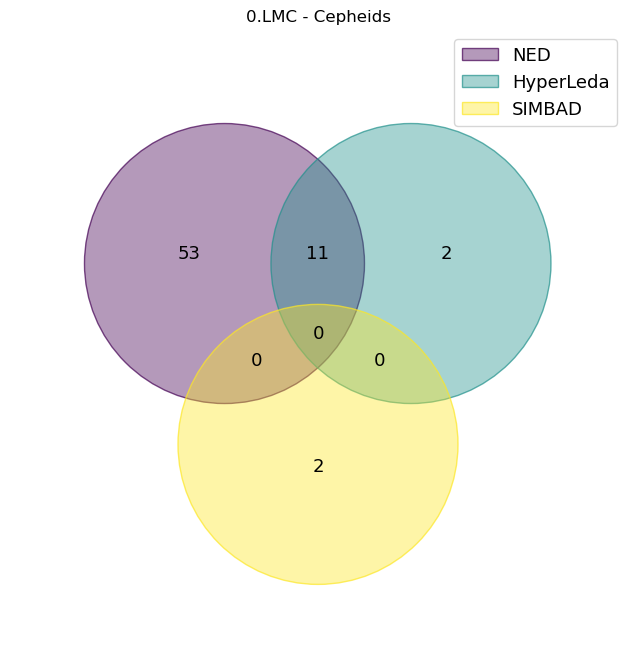

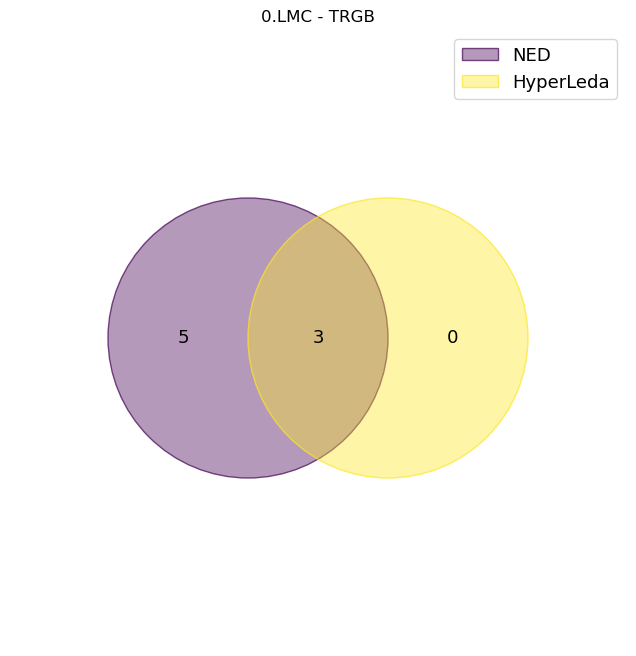

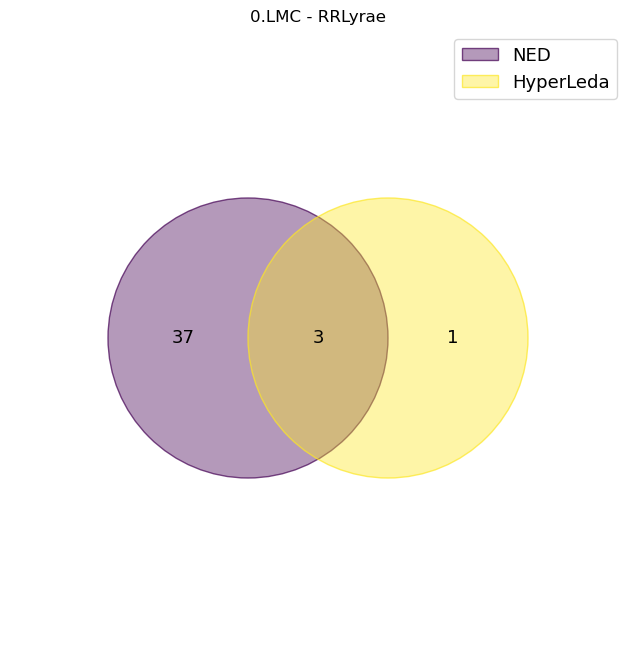

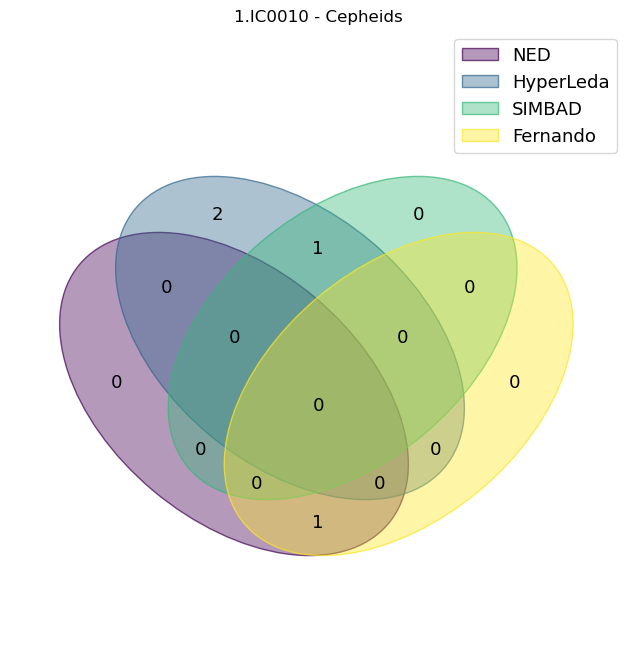

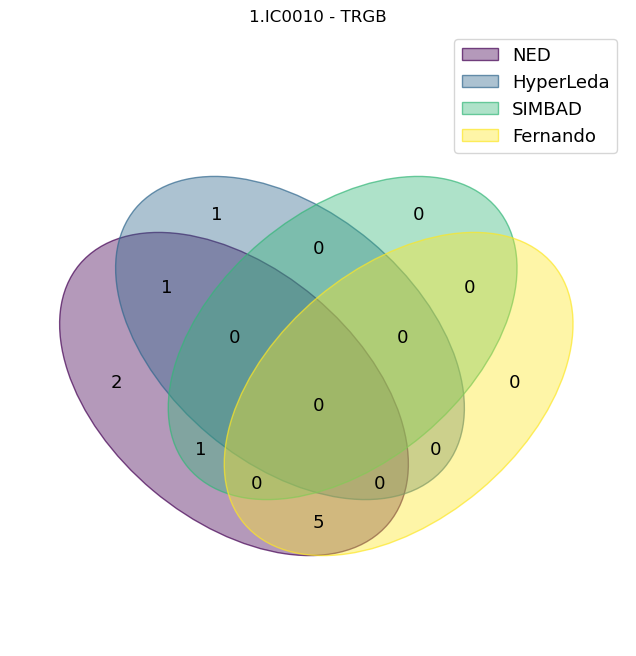

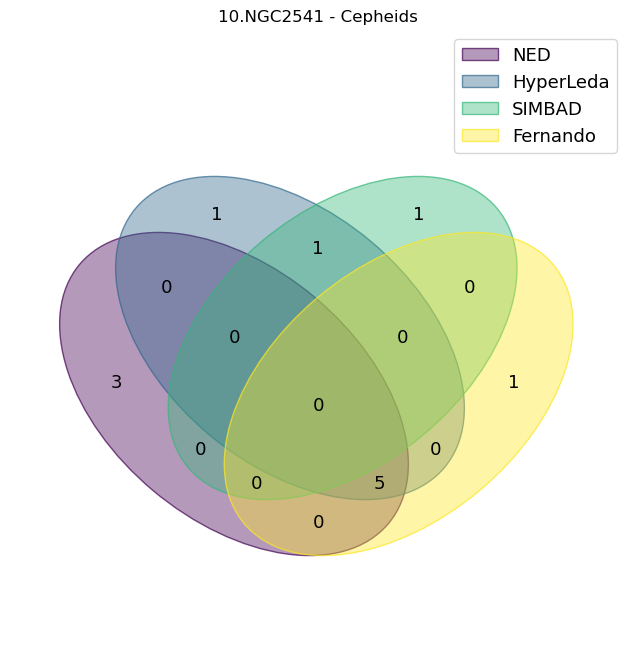

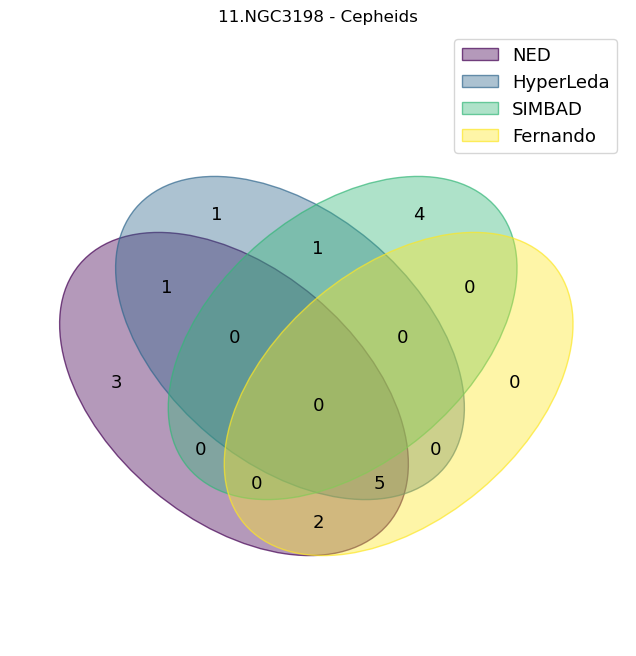

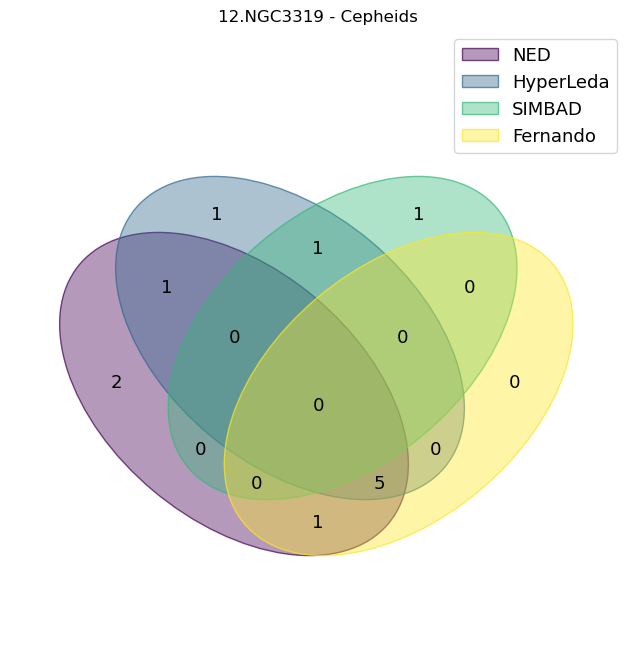

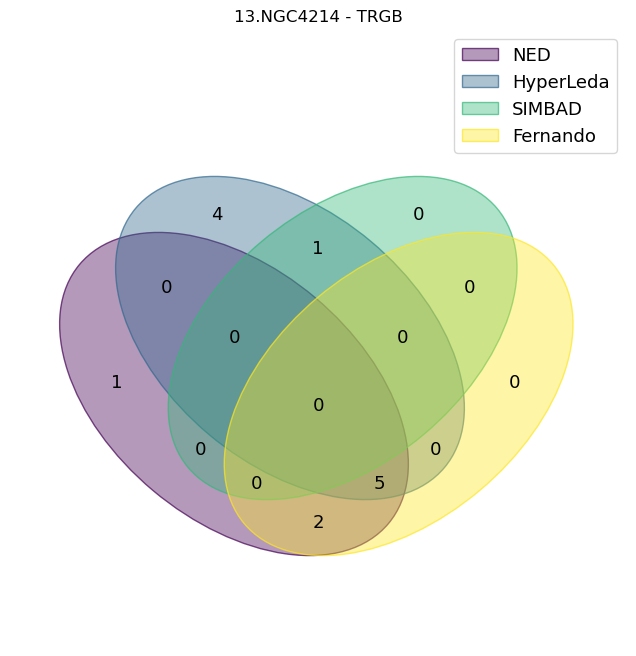

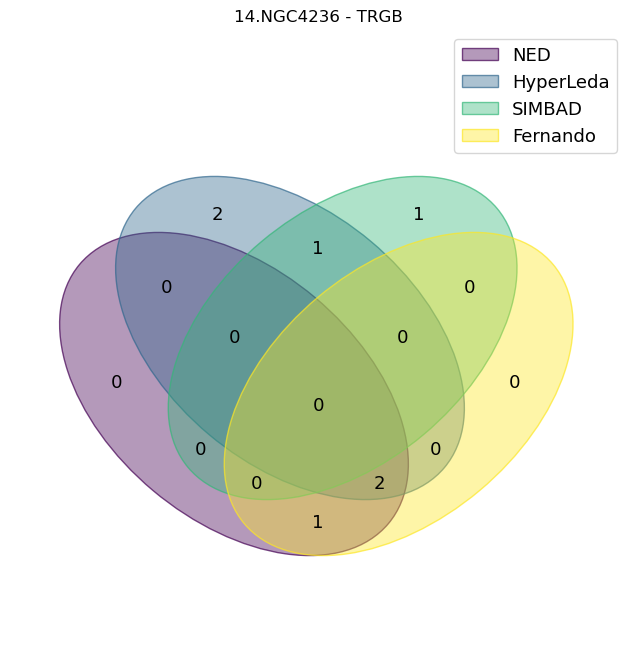

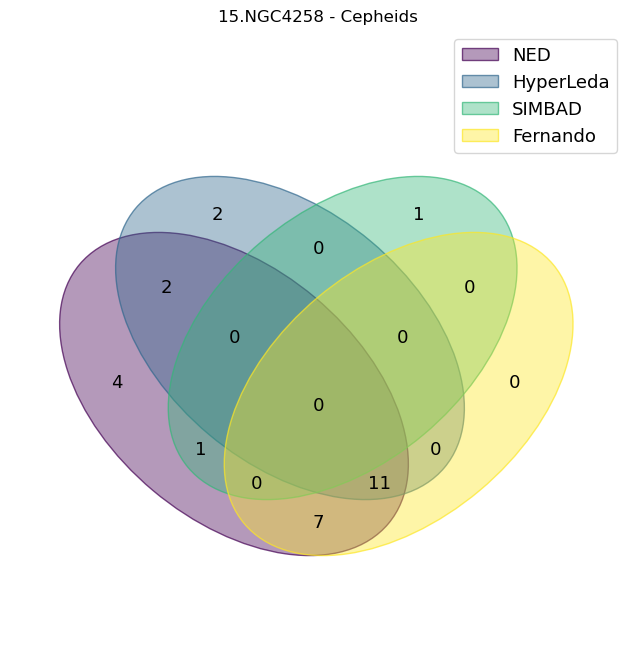

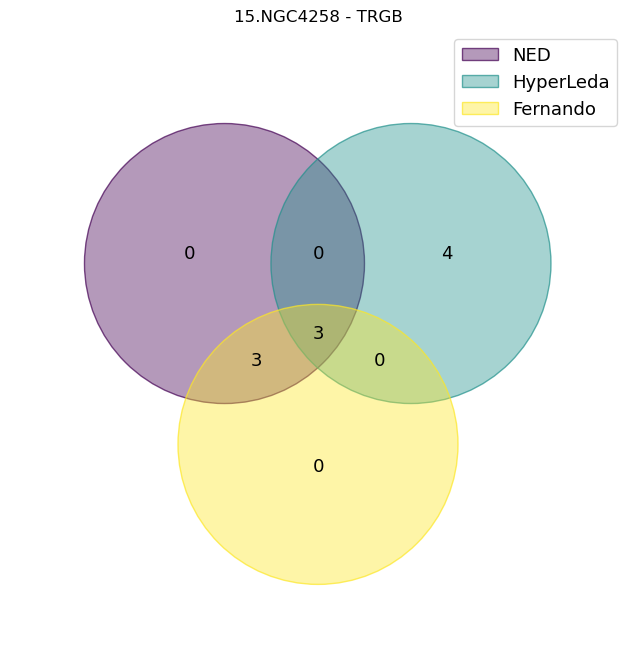

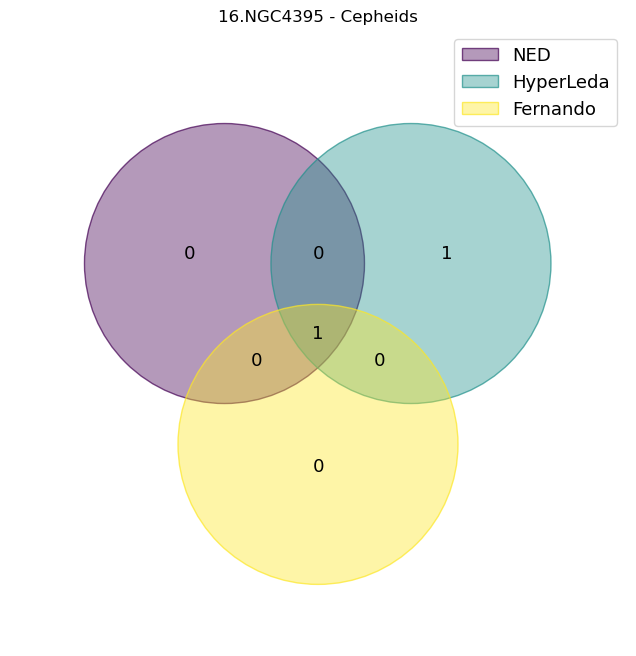

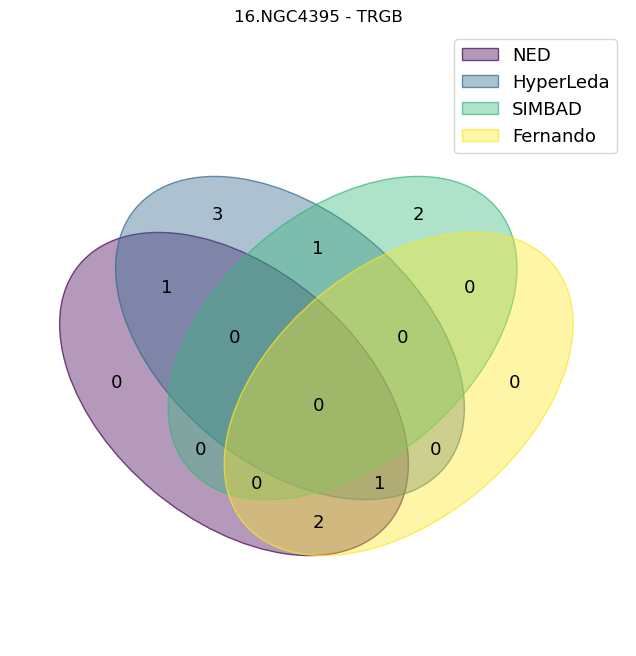

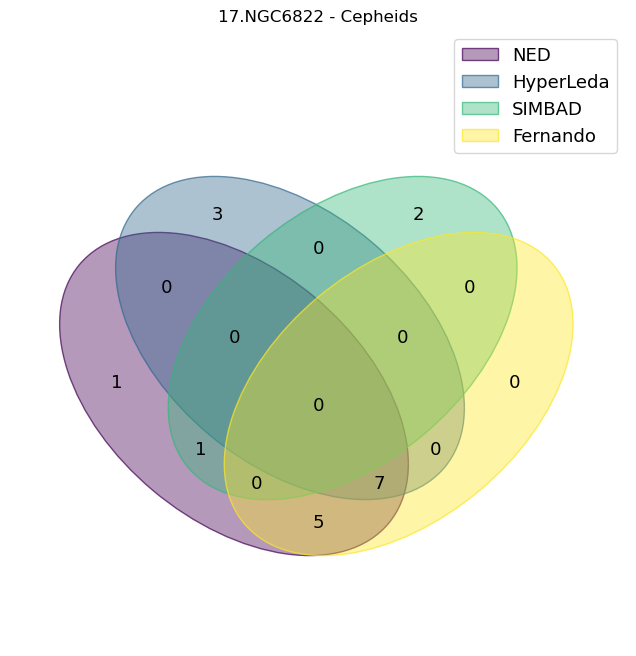

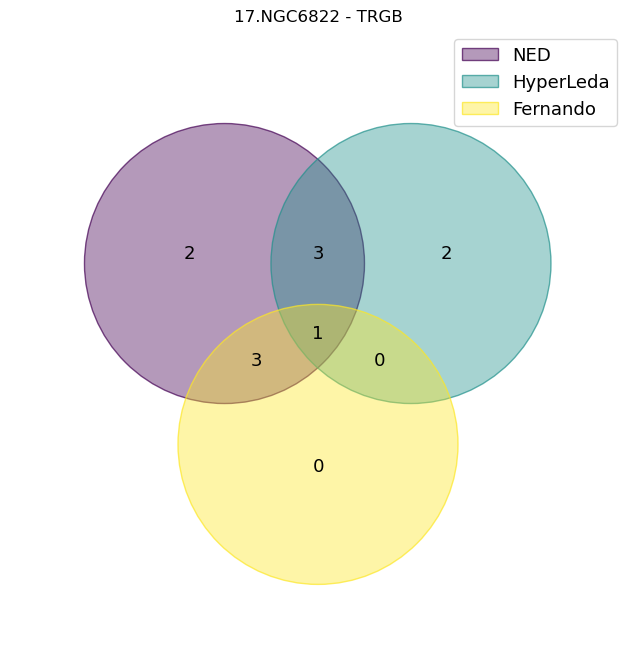

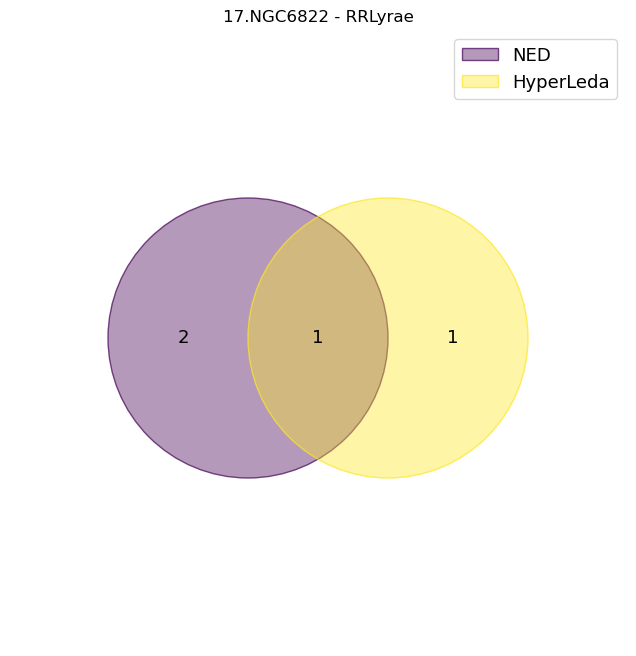

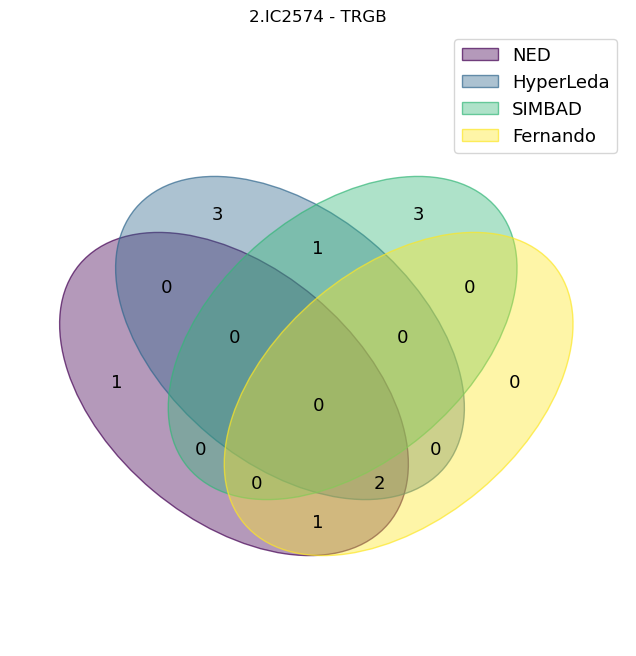

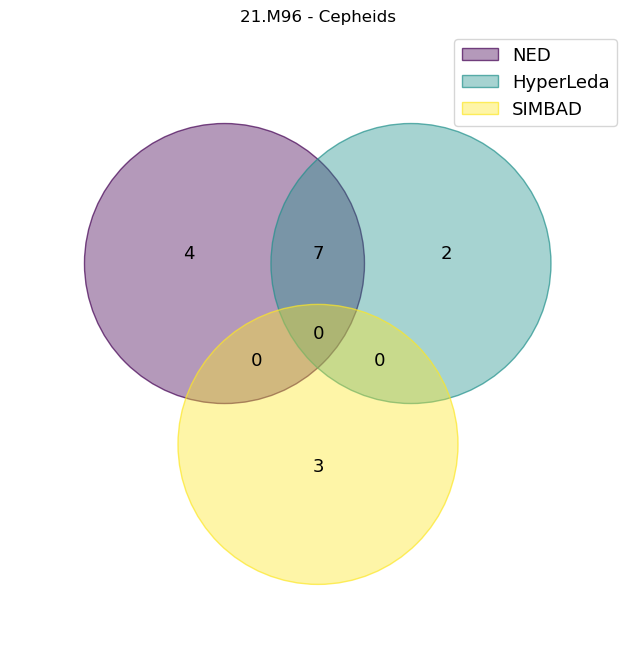

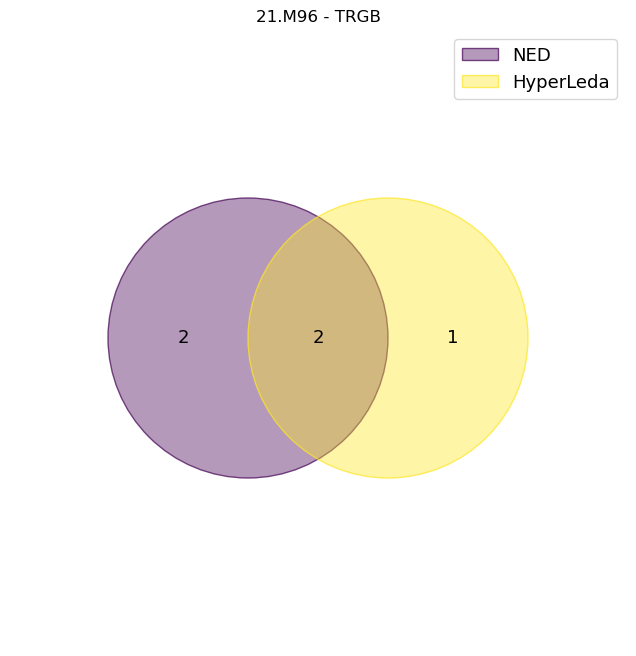

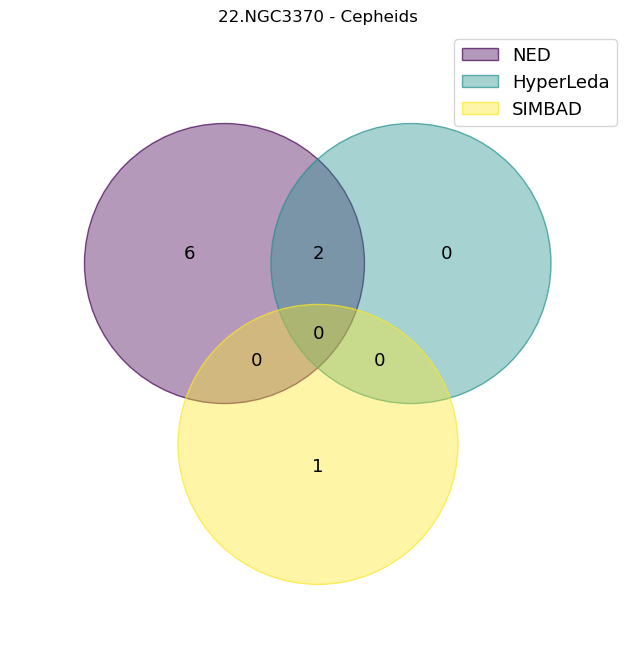

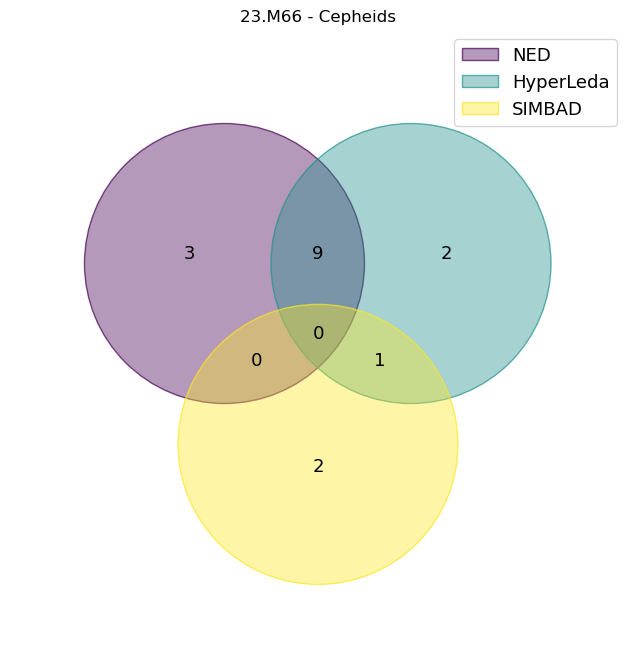

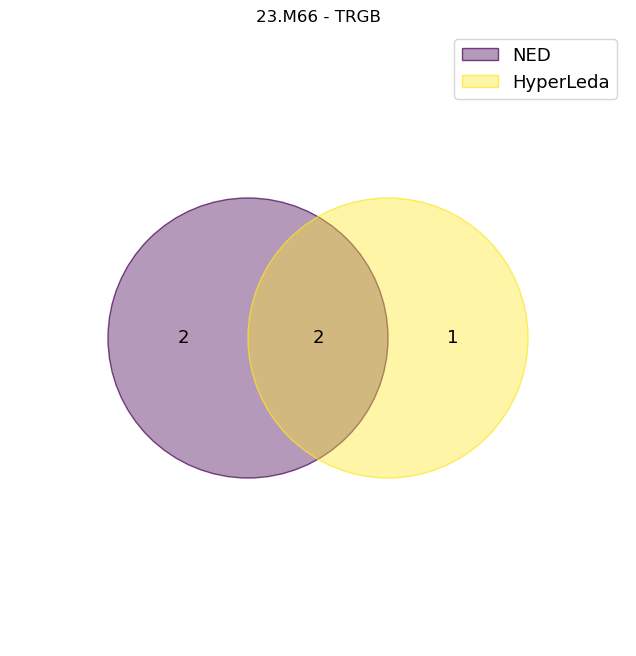

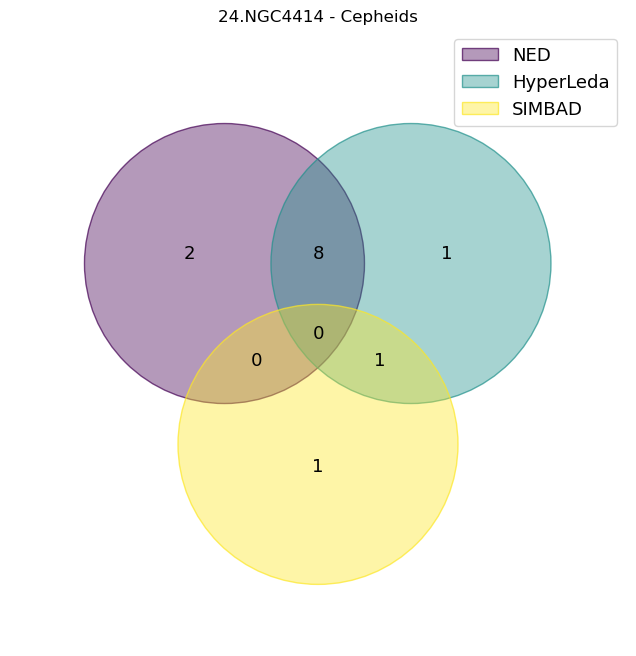

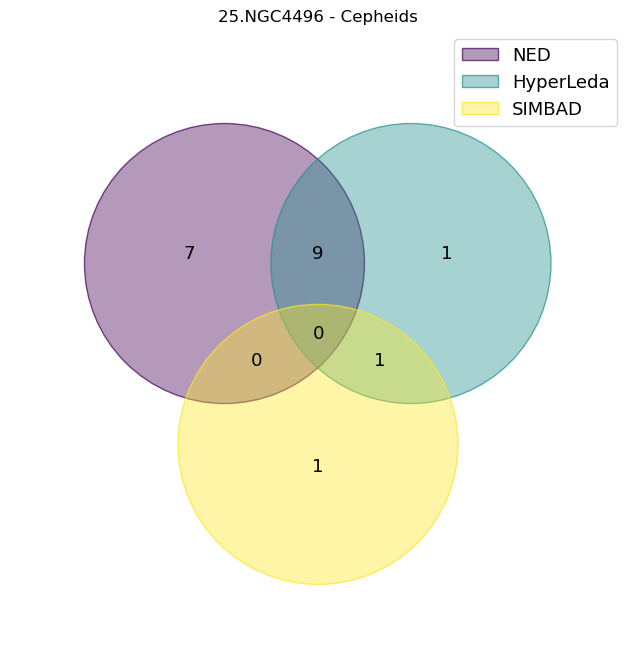

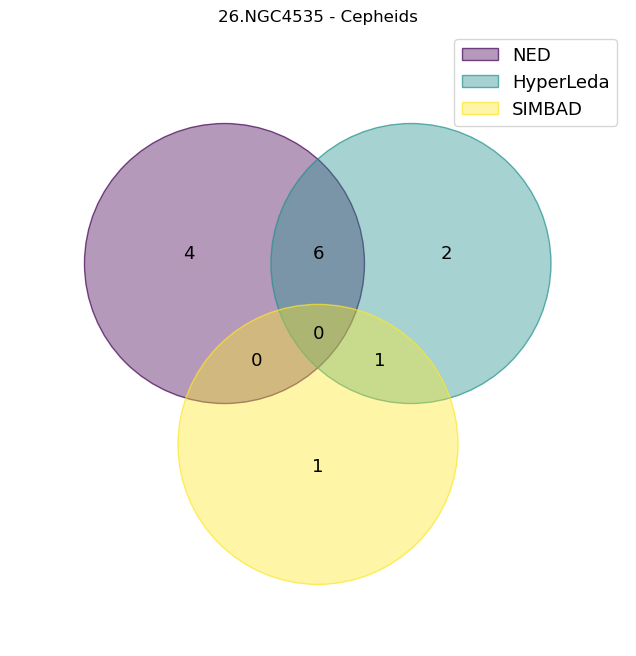

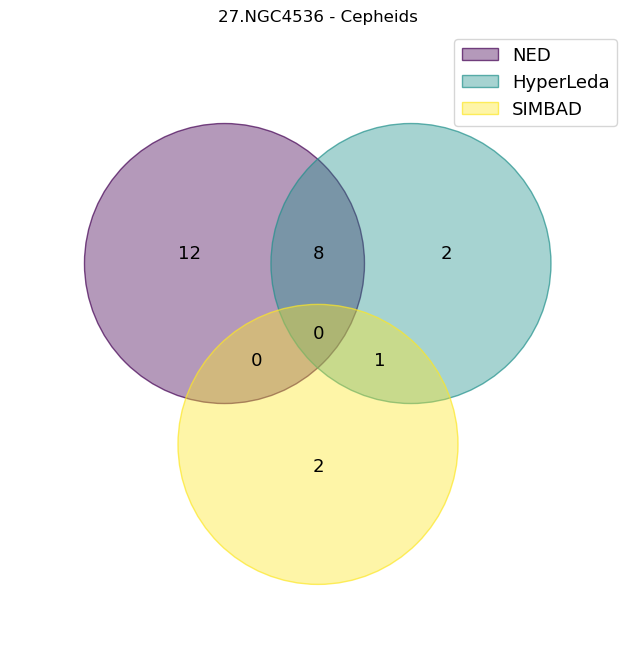

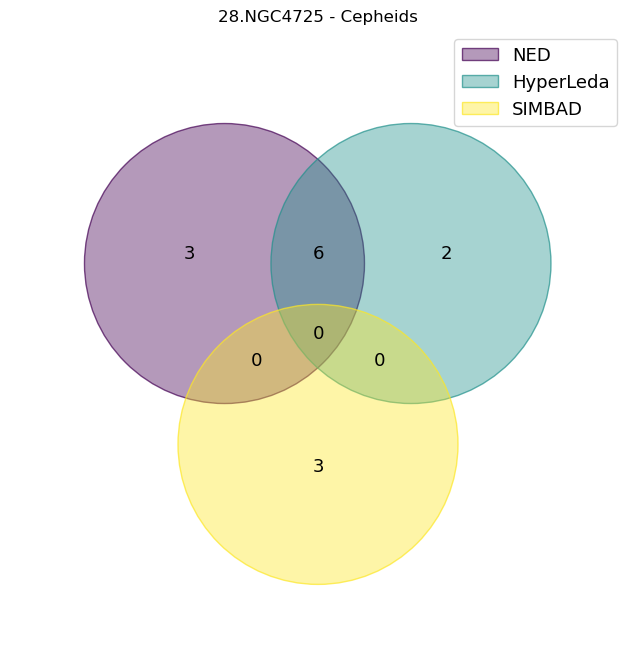

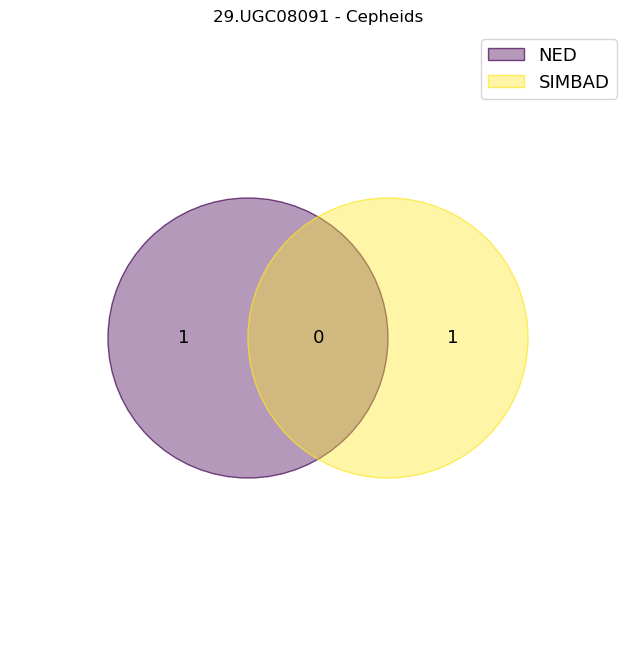

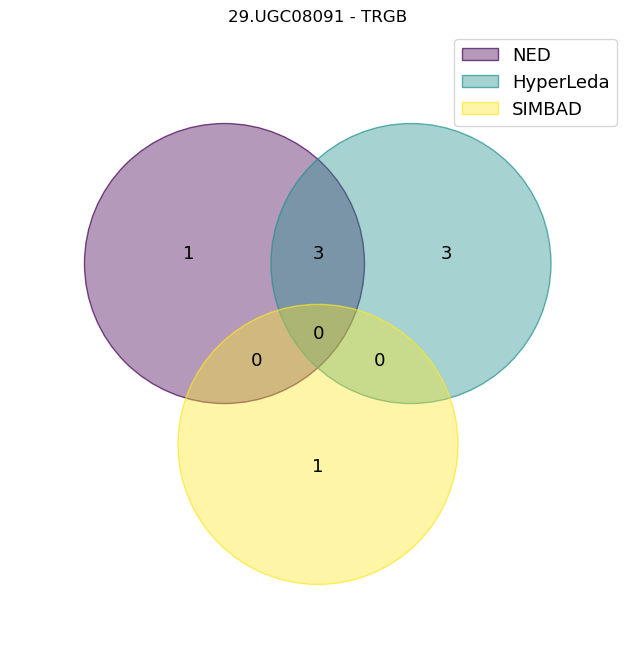

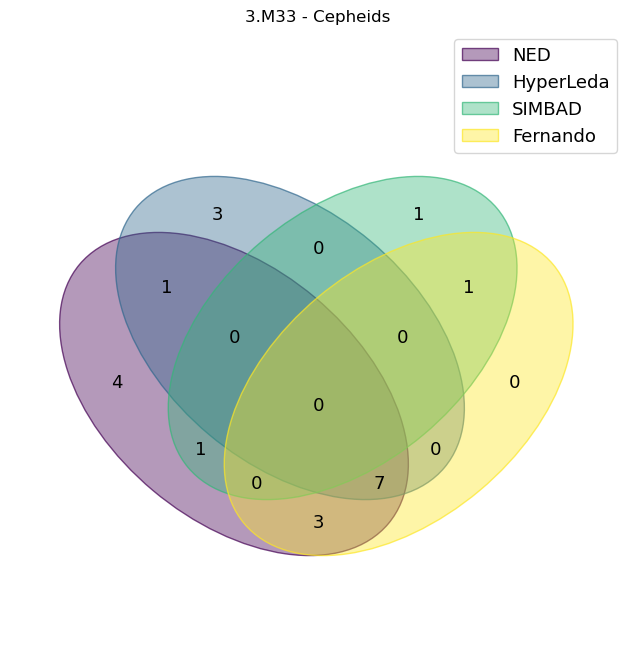

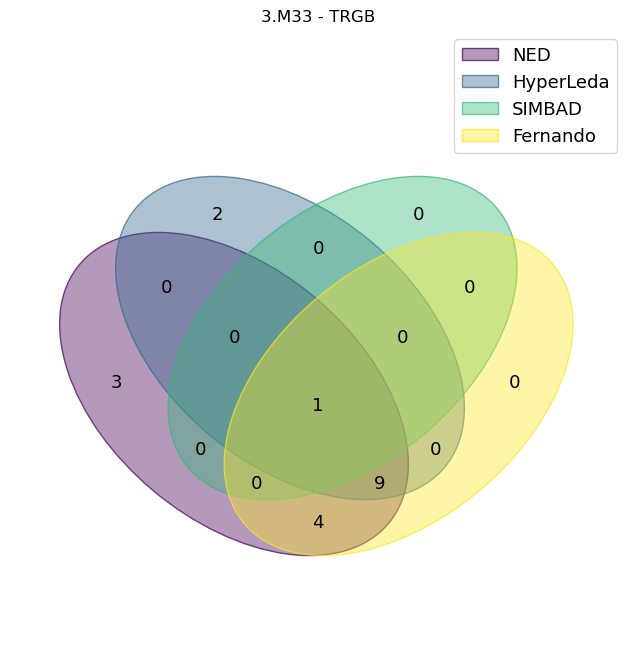

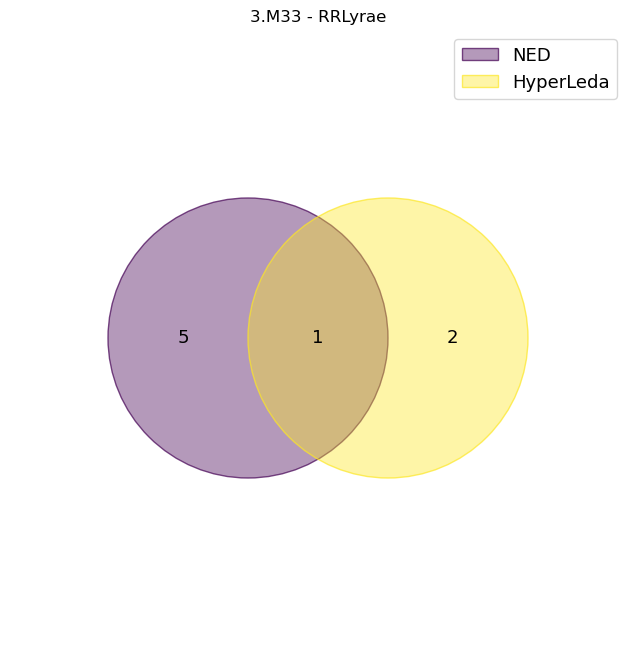

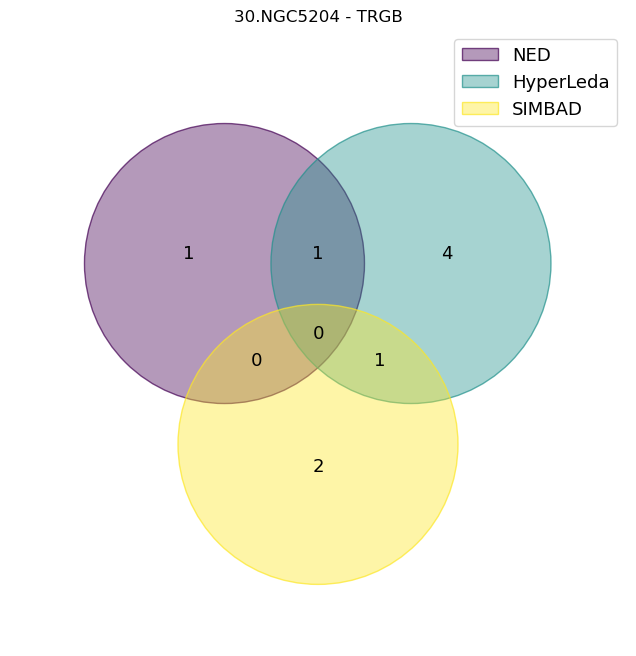

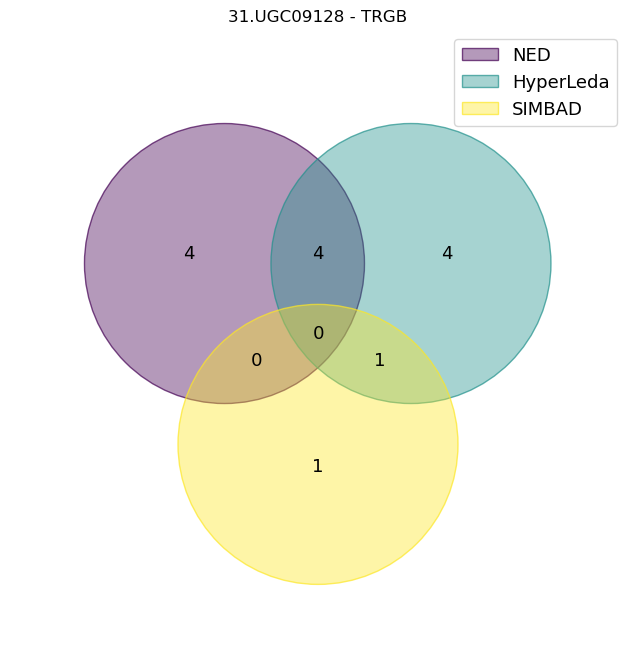

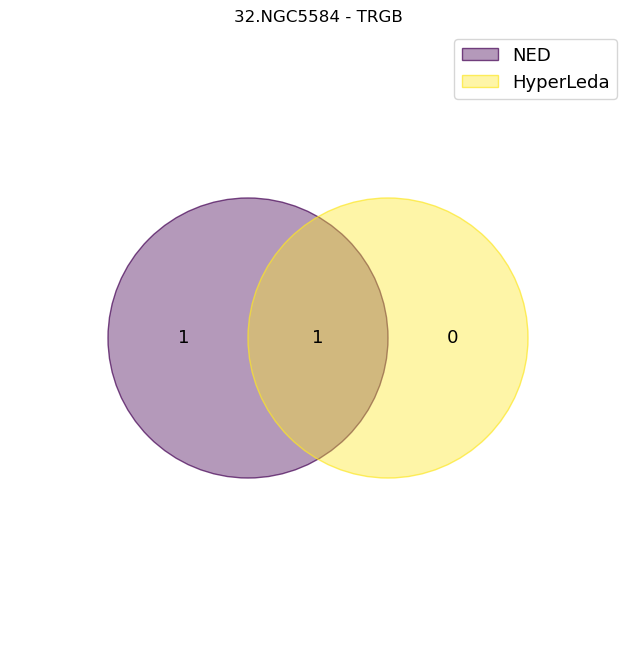

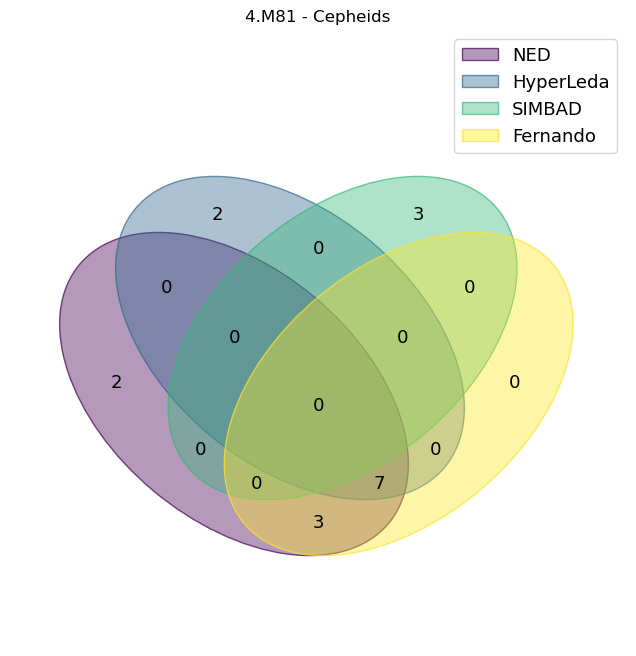

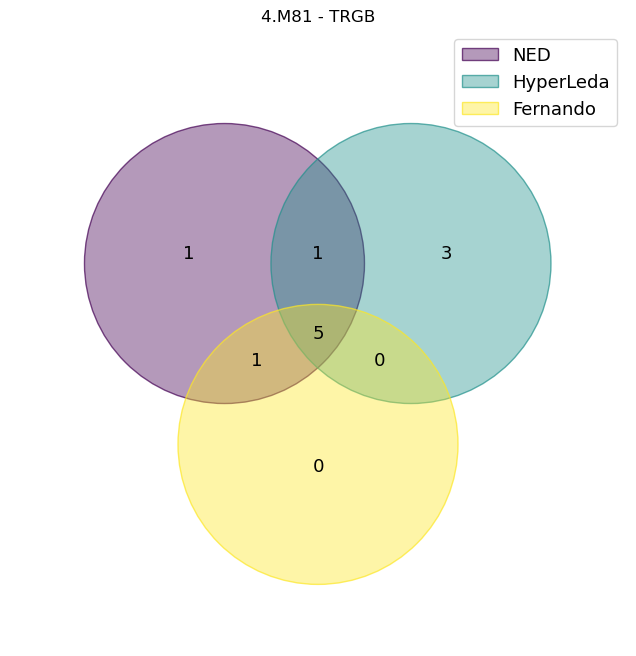

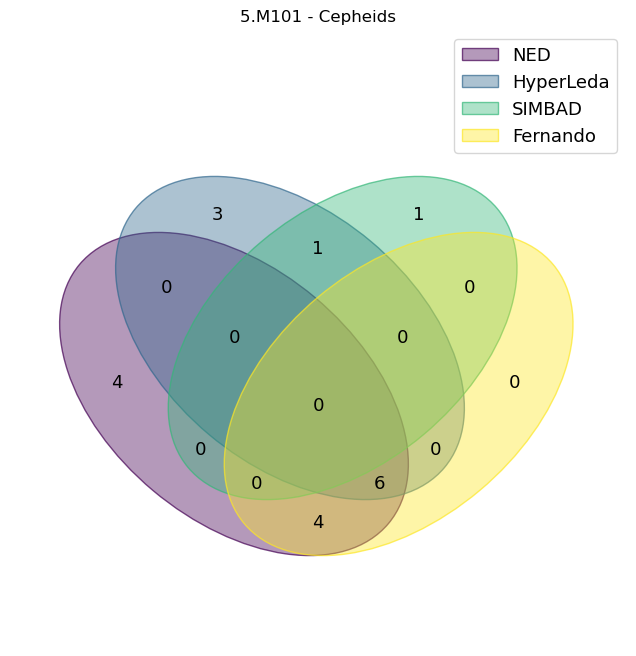

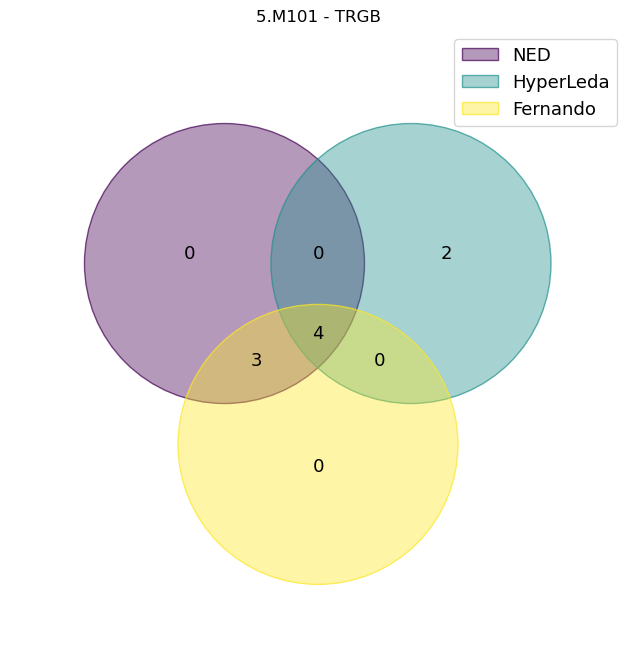

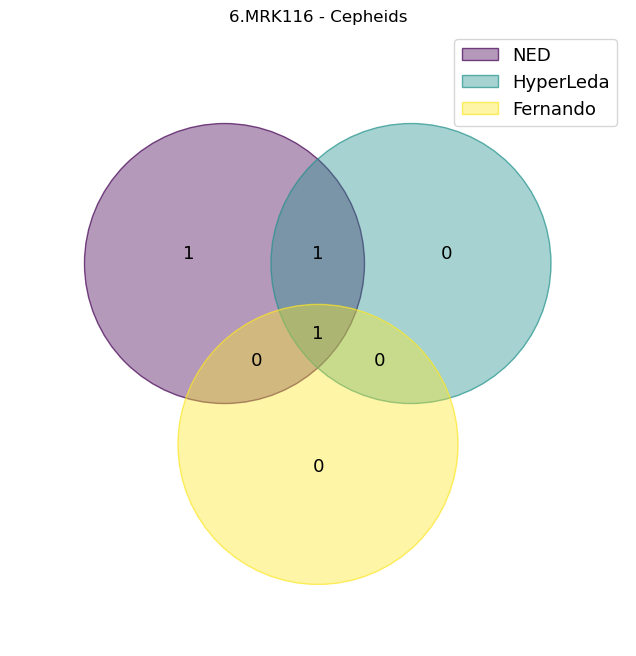

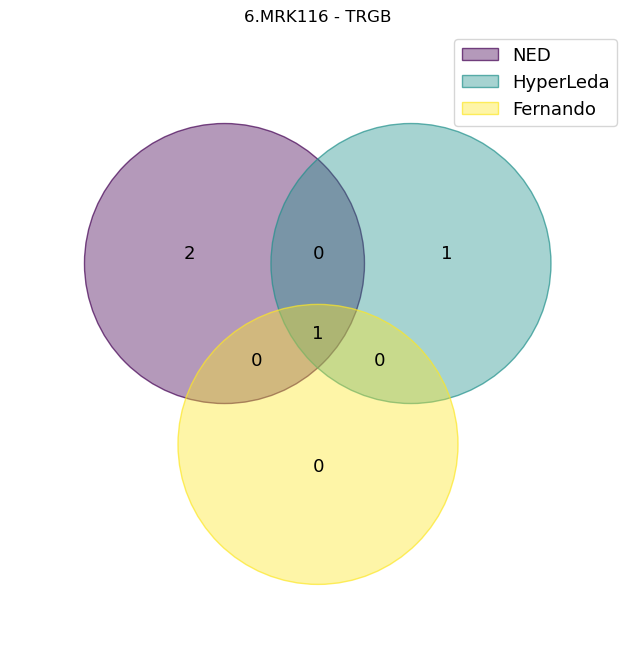

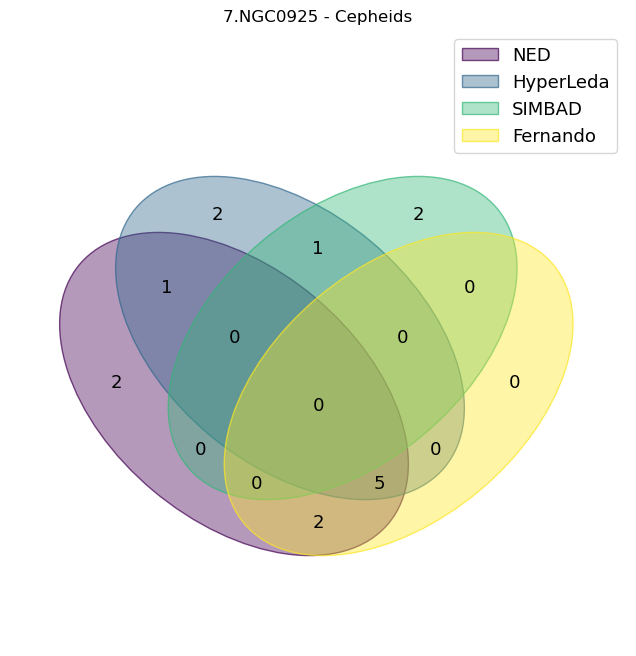

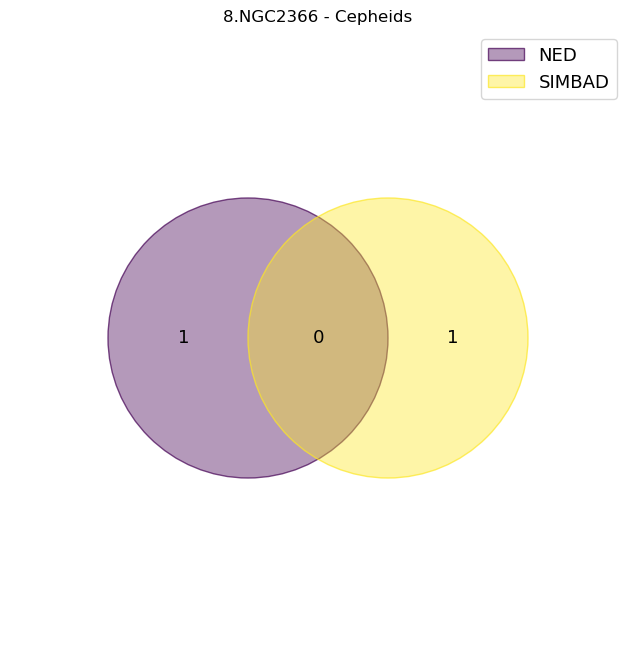

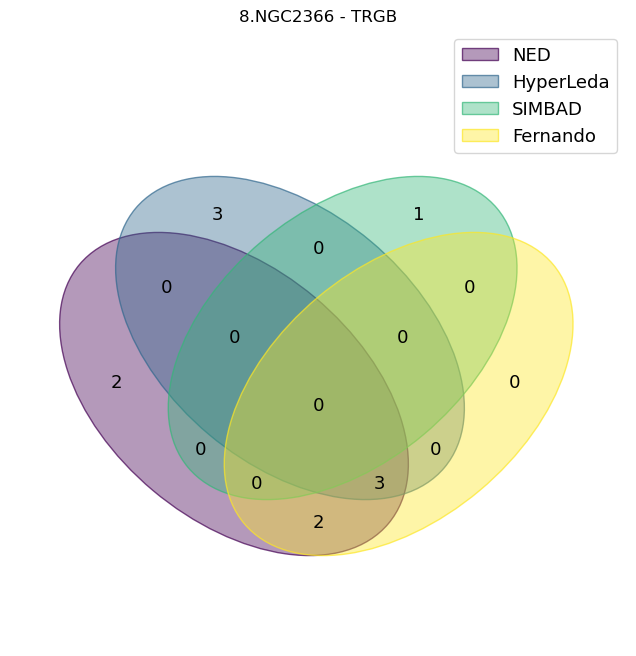

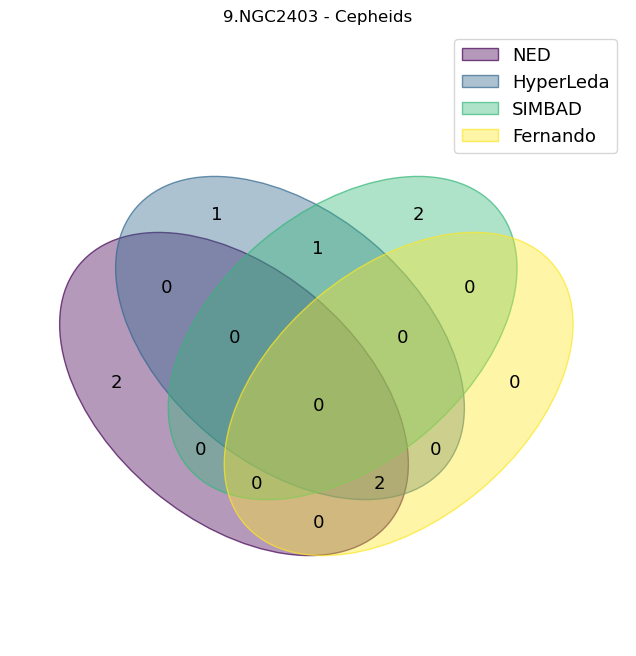

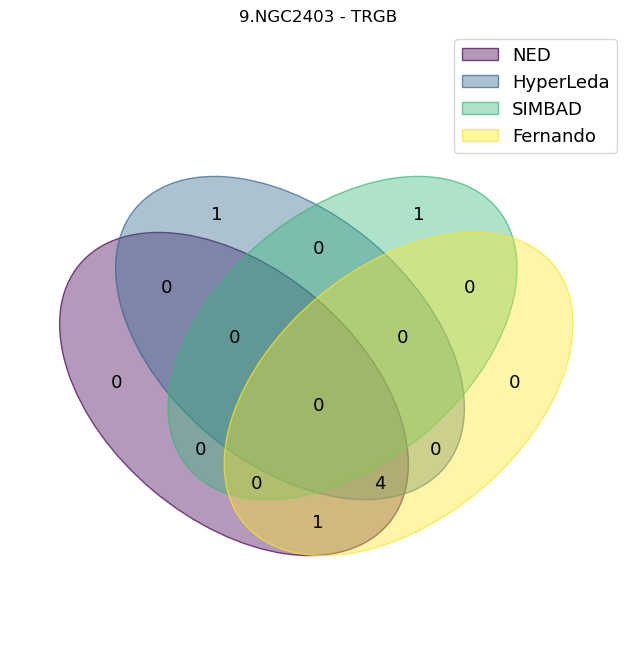

In [88]:
Objetos = np.unique(df_Venn['Galaxy'])

for x in Objetos:
    Venn_plotter(x,df_Venn)

In [89]:
df_Venn = pd.read_csv("/home/hollman/HIIGalaxies/Modulus/REF_Venn/venn_data.txt",
                       sep=',',
                        names=['Source', 'Galaxy', 'Ref','Method'])
NoLMC_data = df_Venn[df_Venn['Galaxy'] != '0.LMC']

NoLMC_data.to_csv("/home/hollman/HIIGalaxies/Modulus/REF_Venn/venn_data_NoLMC.txt", index=False, header=False)

In [90]:
Final_list = pd.read_csv("/home/hollman/HIIGalaxies/Modulus/REF_Venn/venn_data_NoLMC.txt",
                       sep=',',
                        names=['Source', 'Galaxy', 'Ref','Method'])

articulos = np.unique(Final_list['Ref'])
articulos.sort()
len(articulos)

157

In [97]:
GEHR_hosts = np.unique(Final_list['Galaxy']).tolist()
GEHR_hosts.sort(key=lambda x: int(x.split('.')[0]))
GEHR_hosts = np.array(GEHR_hosts)
source_methods = np.array(['Fernando', 'NED', 'HyperLeda','SIMBAD','Chavez','Cepheids','TRGB','RRLyrae','NoID'])

header_array =np.concatenate((source_methods,GEHR_hosts))
header_array

array(['Fernando', 'NED', 'HyperLeda', 'SIMBAD', 'Chavez', 'Cepheids',
       'TRGB', 'RRLyrae', 'NoID', '1.IC0010', '2.IC2574', '3.M33',
       '4.M81', '5.M101', '6.MRK116', '7.NGC0925', '8.NGC2366',
       '9.NGC2403', '10.NGC2541', '11.NGC3198', '12.NGC3319',
       '13.NGC4214', '14.NGC4236', '15.NGC4258', '16.NGC4395',
       '17.NGC6822', '18.NGC1073', '19.NGC2500', '20.NGC3184', '21.M96',
       '22.NGC3370', '23.M66', '24.NGC4414', '25.NGC4496', '26.NGC4535',
       '27.NGC4536', '28.NGC4725', '29.UGC08091', '30.NGC5204',
       '31.UGC09128', '32.NGC5584'], dtype='<U11')

In [98]:
Final_list

,Source,Galaxy,Ref,Method
0,NED,1.IC0010,2000ApJ...529..745F,Cepheids
1,NED,1.IC0010,2000ApJ...529..745F,TRGB
2,NED,1.IC0010,2001ApJ...559..225H,TRGB
3,NED,1.IC0010,2007ApJ...662..272V,TRGB
4,NED,1.IC0010,2008ApJ...688L..69S,TRGB
...,...,...,...,...
983,Fernando,17.NGC6822,2012A&A...540A..49M,TRGB
984,Chavez,18.NGC1073,2021AstBu..76..255T,NoID
985,Chavez,25.NGC4496,1996ApJS..107..693S,NoID
986,Chavez,20.NGC3184,2021MNRAS.501.3621A,NoID


In [94]:
Articulos_info = []

with open("/home/hollman/HIIGalaxies/Modulus/REF_Venn/articles_track.txt", "a+") as f:
    f.write(f"Bibcode,{','.join(map(str, header_array))}\n")


for e in articulos:
    item = Final_list[Final_list['Ref']==e]
    #print(item)

    # Bibcode , Checked(Fernando), NED, HyperLeda, SIMBAD, Chavez, PLRC, TRGB, RRLyrae, NoID,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32

    fuentes = np.unique(item['Source'])
    metodo = np.unique(item['Method'])
    gal_host = np.unique(item['Galaxy'])
    filterby_bib = np.concatenate((fuentes,metodo,gal_host))


    matching = np.isin(header_array,filterby_bib)
    matching = np.where(matching, 1, 0)   


    with open("/home/hollman/HIIGalaxies/Modulus/REF_Venn/articles_track.txt", "a+") as f:
        #f.write(f"{e} {matching}\n")
        f.write(f"{e},{','.join(map(str, matching))}\n")


    #print(e," ",fuentes," ",gal_host," ",metodo)
    #print("\n")
    #print(filterby_bib,"\n")
    #print(e,matching,"\n")







In [95]:
Finally = pd.read_csv("/home/hollman/HIIGalaxies/Modulus/REF_Venn/articles_track.txt")
Finally.sort_values(by=['Fernando', 'Bibcode', 'NED','HyperLeda','SIMBAD','Chavez','Cepheids','TRGB','RRLyrae','NoID'],inplace=True)
Finally.to_csv("/home/hollman/HIIGalaxies/Modulus/REF_Venn/articles_track_sorted.txt", index=False)


## Article apereance in Fernando's work

In [96]:
Sorted_articles = pd.read_csv("/home/hollman/HIIGalaxies/Modulus/REF_Venn/articles_track_sorted.txt")

articles  = Sorted_articles[Sorted_articles['Fernando']==1]['Bibcode'].tolist()





In [119]:
#!pip install pyfiglet
#!pip install install colorama

import pyfiglet
#from colorama import Fore


fig = pyfiglet.Figlet(font='letters')
text = fig.renderText('31.UGC09128')

with open('GalTitle.txt', 'w') as file:
    # Write the content to the file
    file.write(text)

with open('GalTitle.txt', 'r') as file:
    content = file.read()
    print(content)


333333   1      UU   UU   GGGG   CCCCC   00000           1   2222    88888  
   3333 111     UU   UU  GG  GG CC    C 00   00  99999  111 222222  88   88 
  3333   11     UU   UU GG      CC      00   00 99   99  11     222  88888  
    333  11 ... UU   UU GG   GG CC    C 00   00  999999  11  2222   88   88 
333333  111 ...  UUUUU   GGGGGG  CCCCC   00000      99  111 2222222  88888  
                                                  999                       



In [9]:
content.replace('1.IC0010_PLRC', '1.IC0010_TRGB')

' 1      IIIII  CCCCC   00000   00000   1   00000          PPPPPP  LL      \n111      III  CC    C 00   00 00   00 111 00   00         PP   PP LL      \n 11      III  CC      00   00 00   00  11 00   00         PPPPPP  LL      \n 11 ...  III  CC    C 00   00 00   00  11 00   00         PP      LL      \n111 ... IIIII  CCCCC   00000   00000  111  00000  _______ PP      LLLLLLL \n                                                                          \nRRRRRR   CCCCC  \nRR   RR CC    C \nRRRRRR  CC      \nRR  RR  CC    C \nRR   RR  CCCCC  \n                \n'